In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,6)
sns.set_style("whitegrid")

In [ ]:

# Visualization

df = pd.read_csv("data/raw_esg_financial_data.csv")
df.head()

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


In [3]:

df.columns.tolist()

['CompanyID',
 'CompanyName',
 'Industry',
 'Region',
 'Year',
 'Revenue',
 'ProfitMargin',
 'MarketCap',
 'GrowthRate',
 'ESG_Overall',
 'ESG_Environmental',
 'ESG_Social',
 'ESG_Governance',
 'CarbonEmissions',
 'WaterUsage',
 'EnergyConsumption']

In [ ]:
# Visualization

esg_cols = [col for col in df.columns if any(x in col.lower() for x in ['esg','environment','social','governance'])]
financial_cols = [col for col in df.columns if any(x in col.lower() for x in ['revenue','profit','income','margin','market','cap','invest','fund','cost','risk','growth'])]

esg_cols, financial_cols

(['ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance'],
 ['Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate'])

In [ ]:

# Exploratory Visual Analysis

if 'ESG_Index' not in df.columns:
    df['ESG_Index'] = df[esg_cols].mean(axis=1)

df[['ESG_Index']].describe()

,ESG_Index
count,11000.000000
mean,54.615125
std,15.894133
min,6.300000
25%,44.125000
50%,54.575000
75%,65.600000
max,98.775000


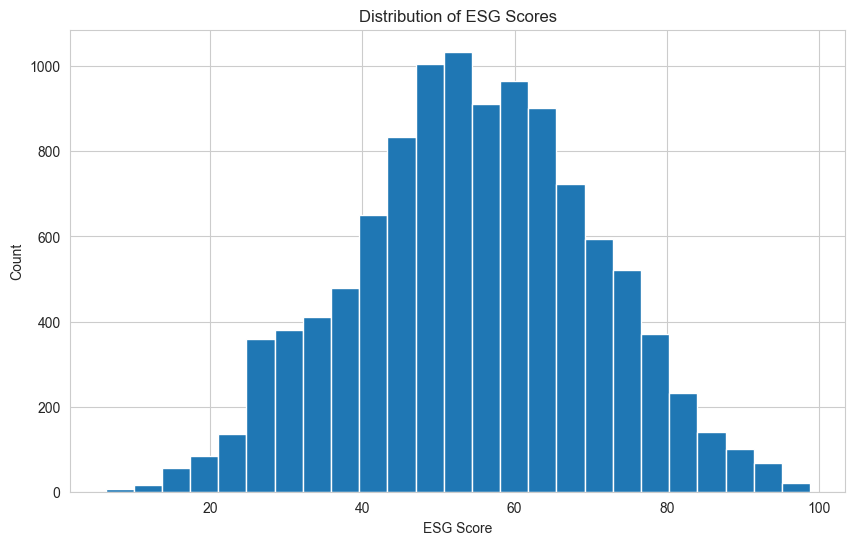

In [ ]:
#Bar/ Distribution charts

plt.hist(df['ESG_Index'], bins=25)
plt.title("Distribution of ESG Scores")
plt.xlabel("ESG Score")
plt.ylabel("Count")
plt.show()

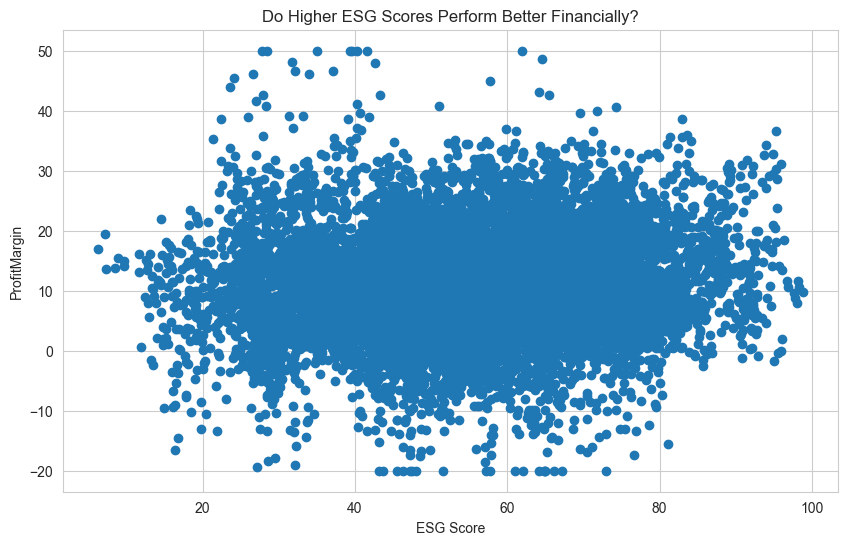

In [ ]:

# BUSINESS QUESTION - 1  
# Do companies with higher ESG scores perform better financially compared to others?

if 'profit' in " ".join(df.columns).lower():
    target = [c for c in df.columns if 'profit' in c.lower()][0]
elif 'income' in " ".join(df.columns).lower():
    target = [c for c in df.columns if 'income' in c.lower()][0]
else:
    target = financial_cols[0]

plt.scatter(df['ESG_Index'], df[target])
plt.title("Do Higher ESG Scores Perform Better Financially?")
plt.xlabel("ESG Score")
plt.ylabel(target)
plt.show()

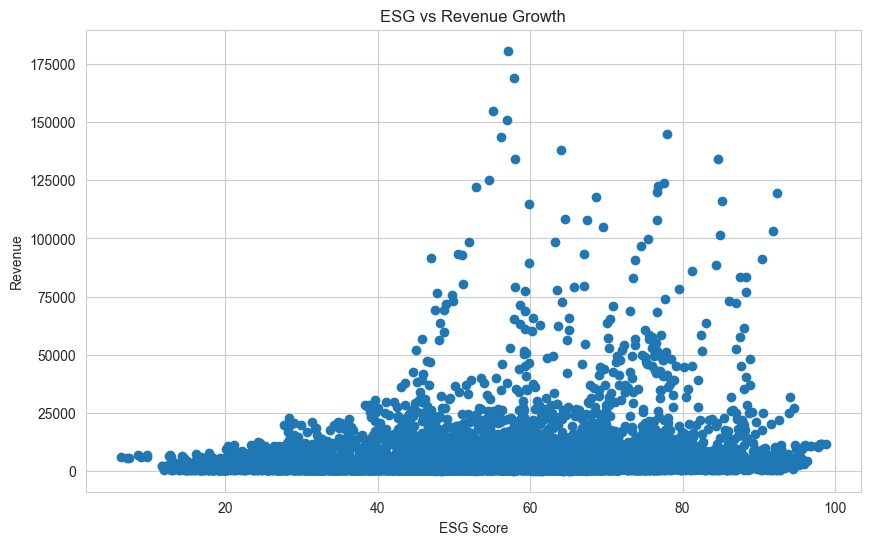

In [ ]:
# BUSINESS QUESTION - 2  
# Is there a measurable relationship between ESG performance and revenue growth or profitability?

growth_cols = [c for c in df.columns if any(x in c.lower() for x in ['growth','revenue'])]

if len(growth_cols) > 0:
    plt.scatter(df['ESG_Index'], df[growth_cols[0]])
    plt.title("ESG vs Revenue Growth")
    plt.xlabel("ESG Score")
    plt.ylabel(growth_cols[0])
    plt.show()

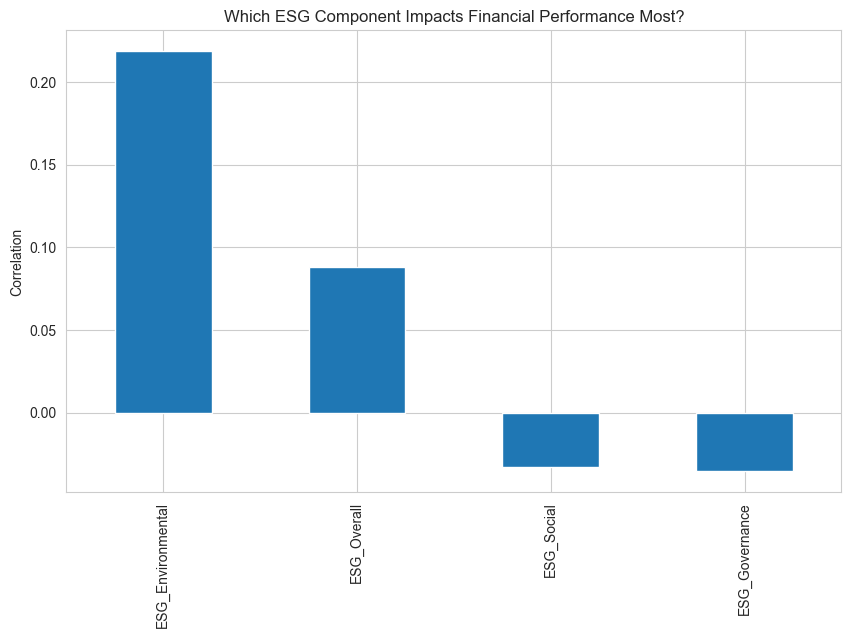

In [ ]:
# BUSINESS QUESTION - 3   
# Which component of ESG (Environmental, Social, or Governance) has the most significant impact on financial performance?

impact_cols = esg_cols + [target]
corr = df[impact_cols].corr()[target].sort_values(ascending=False)

corr.drop(target).plot(kind='bar')
plt.title("Which ESG Component Impacts Financial Performance Most?")
plt.ylabel("Correlation")
plt.show()

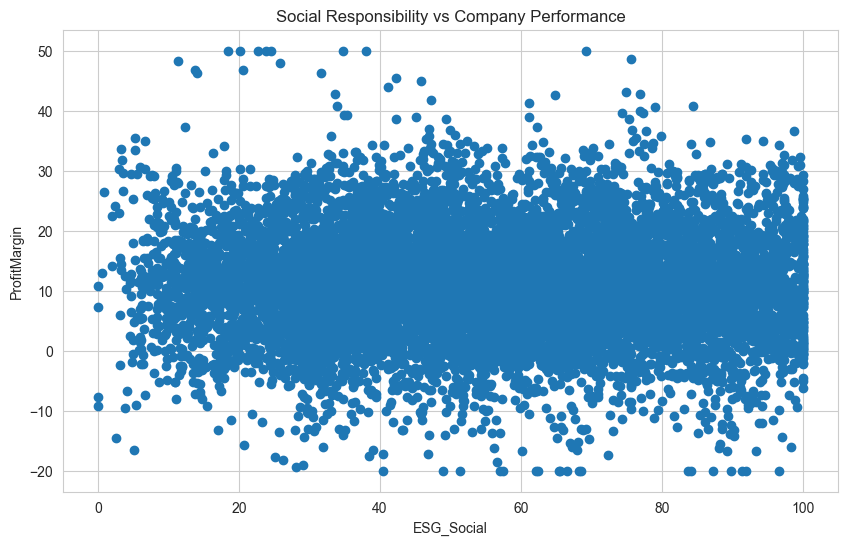

In [ ]:
# BUSINESS QUESTION - 4  
# How does social responsibility (employee satisfaction, diversity, etc.) influence company performance?

social_cols = [c for c in df.columns if 'social' in c.lower()]

if len(social_cols) > 0:
    plt.scatter(df[social_cols[0]], df[target])
    plt.title("Social Responsibility vs Company Performance")
    plt.xlabel(social_cols[0])
    plt.ylabel(target)
    plt.show()

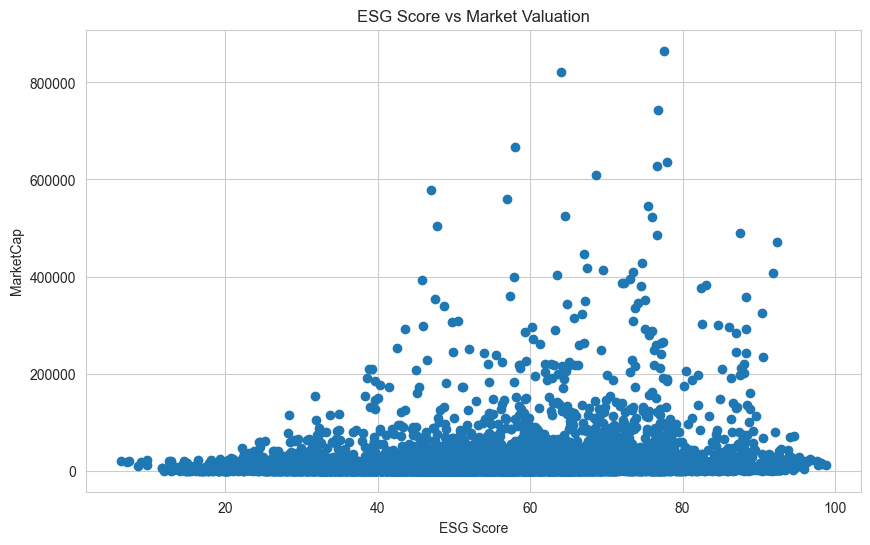

In [ ]:
# BUSINESS QUESTION - 5  
# Is there a correlation between ESG scores and market valuation (market cap)?

mcap_cols = [c for c in df.columns if 'market' in c.lower() or 'cap' in c.lower()]

if len(mcap_cols) > 0:
    plt.scatter(df['ESG_Index'], df[mcap_cols[0]])
    plt.title("ESG Score vs Market Valuation")
    plt.xlabel("ESG Score")
    plt.ylabel(mcap_cols[0])
    plt.show()

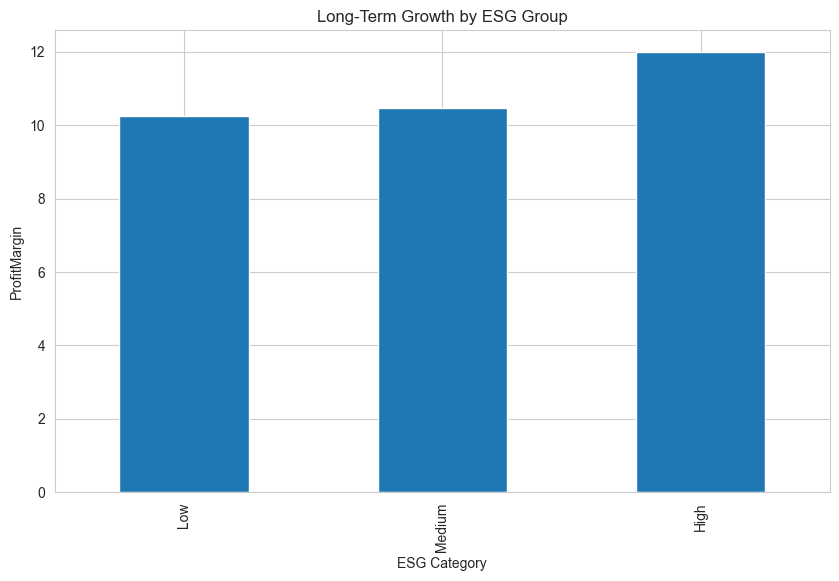

In [ ]:
# BUSINESS QUESTION - 6
# How does ESG performance impact long-term business sustainability and growth?

df['ESG_Group'] = pd.qcut(df['ESG_Index'], q=3, labels=['Low','Medium','High'])

group_perf = df.groupby('ESG_Group')[target].mean()

group_perf.plot(kind='bar')
plt.title("Long-Term Growth by ESG Group")
plt.xlabel("ESG Category")
plt.ylabel(target)
plt.show()

In [ ]:
# BUSINESS QUESTION - 7 
# Can ESG metrics be used as a reliable factor in long-term investment decision-making? 

corr_all = df[['ESG_Index'] + financial_cols].corr()['ESG_Index'].sort_values(ascending=False)
corr_all

ESG_Index       1.000000
Revenue         0.148907
MarketCap       0.143824
ProfitMargin    0.087982
GrowthRate      0.068234
Name: ESG_Index, dtype: float64